## Analisis de Clusters

In [2]:
# Cargar librerias:
import pandas as pd
import numpy as np
from scipy import stats
import os

In [3]:
# Cargar datos:
path = os.path.join('Datos', 'Transformados', 'df_limpio_con_clusters.csv')
df = pd.read_csv(path)

In [52]:
# Analisis datos:
df.columns

Index(['booked_at', 'checkin_time', 'lead_time', 'lenght_of_stay',
       'checkin_month', 'checkin_day', 'adult_count', 'child_count', 'origin',
       'travel_agency_name', 'requested_category', 'requested_category_name',
       'asset', 'asset_type', 'brand', 'available_units', 'business_segment',
       'rate', 'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'returning_inhabitant', 'recurrence',
       'libere_community', 'bought_products', 'product_count',
       'reservation_net_value', 'total_adr', 'status', 'cancellation_reason',
       'cancellation_lead_time', 'City', 'Reserva_Dia_Semana',
       'Cancelacion_Dia_Semana', 'Estacion_Cancelacion', 'Estacion_Estancia',
       'Estacion_Reserva', 'zona_roja_mes', 'momento_checkin',
       'total_personas_adult_y_niños', 'ratio_formularios',
       'reservation_checkin_month_diff', 'estancia_en_festivo',
       'estancia_en_finde', 'mes_checkin_numerico', 'cluster_kmeans_3'],
    

In [53]:
# COnvertir cada variable a su tipo correspodiente:

# Bucle para convertir tipos correctamente
for col in df.columns:
    # Si es object
    if df[col].dtype == 'object':
        unique_vals = df[col].dropna().astype(str).unique()  # asegurar que sean strings
        
        # Solo 0/1 → booleano
        if set(unique_vals).issubset({'0', '1', 0, 1}):
            df[col] = df[col].astype(bool)
        
        else:
            # Intentar convertir a float
            try:
                df[col] = pd.to_numeric(df[col], errors='raise')
            except:
                # Si no se puede → category
                df[col] = df[col].astype('category')
                
    # Si ya es booleano → opcional convertir a int
    elif df[col].dtype == 'bool':
        df[col] = df[col].astype(int)


# Comprobar tipos finales
print(df["rate"].dtypes)

category


In [54]:
print(df.dtypes)

booked_at                         category
checkin_time                      category
lead_time                            int64
lenght_of_stay                       int64
checkin_month                     category
checkin_day                       category
adult_count                          int64
child_count                          int64
origin                            category
travel_agency_name                category
requested_category                category
requested_category_name           category
asset                             category
asset_type                        category
brand                             category
available_units                      int64
business_segment                  category
rate                              category
rate_group_name                   category
rate_type                         category
completed_entry_forms_count        float64
all_entry_forms_completed         category
returning_inhabitant              category
recurrence 

In [55]:
# Crear nuevas columnas 0/1 a partir de las columnas booleanas originales
df['all_entry_forms_completed'] = df['all_entry_forms_completed'].replace({'yes': 1, 'no': 0}).astype(int)
df['returning_inhabitant']    = df['returning_inhabitant'].replace({'yes': 1, 'no': 0}).astype(int)
df['libere_community']        = df['libere_community'].replace({'yes': 1, 'no': 0}).astype(int)

# Comprobar las primeras filas
print(df[['all_entry_forms_completed',
          'returning_inhabitant',
          'libere_community']].head())


   all_entry_forms_completed  returning_inhabitant  libere_community
0                          1                     1                 0
1                          1                     1                 1
2                          1                     0                 0
3                          1                     0                 0
4                          1                     0                 0


C:\Users\Larau\AppData\Local\Temp\ipykernel_19552\343575335.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['all_entry_forms_completed'] = df['all_entry_forms_completed'].replace({'yes': 1, 'no': 0}).astype(int)
C:\Users\Larau\AppData\Local\Temp\ipykernel_19552\343575335.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['all_entry_forms_completed'] = df['all_entry_forms_completed'].replace({'yes': 1, 'no': 0}).astype(int)
C:\Users\Larau\AppData\Local\Temp\ipykernel_19552\343575335.py:3: FutureWarning: Downcasting behavior in `replace` 

In [56]:
numeric_cols = ['lead_time', 'lenght_of_stay', 'adult_count', 'child_count', 
                'available_units', 'completed_entry_forms_count', 'recurrence',
                'bought_products', 'product_count', 'reservation_net_value',
                'total_adr', 'total_personas_adult_y_niños', 
                'ratio_formularios', 'reservation_checkin_month_diff', 
                'estancia_en_festivo', 'estancia_en_finde', 'mes_checkin_numerico']

categorical_cols = ['checkin_month', 'checkin_day', 'origin', 'travel_agency_name',
                    'requested_category', 'requested_category_name', 'asset',
                    'asset_type', 'brand', 'business_segment', 'rate', 
                    'rate_group_name', 'rate_type', 'all_entry_forms_completed',
                    'returning_inhabitant', 'libere_community', 'status',
                    'cancellation_reason', 'City', 'Reserva_Dia_Semana', 
                    'Cancelacion_Dia_Semana', 'Estacion_Cancelacion',
                    'Estacion_Estancia', 'Estacion_Reserva', 'zona_roja_mes',
                    'momento_checkin']

boolean_cols = ['all_entry_forms_completed', 'returning_inhabitant', 'libere_community']  

In [57]:
# Asegurarse de que las columnas booleanas estén codificadas como 0/1
for col in boolean_cols:
    df[col] = df[col].replace({'Yes': 1, 'No': 0})  # Ajusta según tu dataset

# Seleccionar solo columnas numéricas reales para evitar errores
numeric_cols_real = df[numeric_cols].select_dtypes(include=[np.number]).columns.tolist()

# Media de variables numéricas por cluster
numeric_means = df.groupby("cluster_kmeans_3")[numeric_cols_real].mean()
print("Media variables numéricas por cluster:")
print(numeric_means)


Media variables numéricas por cluster:
                  lead_time  lenght_of_stay  adult_count  child_count  \
cluster_kmeans_3                                                        
0                 31.366451        1.929262     1.686142     0.200548   
1                 27.305076        2.376730     2.409084     0.315394   
2                 28.034466        2.305016     2.354531     0.494903   

                  available_units  completed_entry_forms_count  recurrence  \
cluster_kmeans_3                                                             
0                      131.525474                     1.128116    1.468843   
1                       21.803132                     1.803183    1.250843   
2                      120.000000                     1.734142    2.186570   

                  product_count  reservation_net_value   total_adr  \
cluster_kmeans_3                                                     
0                      0.528564             103.932629   60.1843

In [41]:
# Moda de variables categóricas por cluster
def mode_func(x):
    return x.mode().iloc[0] if not x.mode().empty else np.nan

categorical_modes = df.groupby("cluster_kmeans_3")[categorical_cols].agg(mode_func)
print("\nModa variables categóricas por cluster:")
print(categorical_modes)


Moda variables categóricas por cluster:
                 checkin_month checkin_day           origin  \
cluster_kmeans_3                                              
0                    September      Friday  channel_manager   
1                        April      Friday  channel_manager   
2                       August      Friday  channel_manager   

                 travel_agency_name     requested_category  \
cluster_kmeans_3                                             
0                       Booking.com            Hostel room   
1                       Booking.com                 Studio   
2                       Booking.com  One bedroom apartment   

                                       requested_category_name  \
cluster_kmeans_3                                                 
0                  10 bed community room with ensuite bathroom   
1                                Studio in Madrid Palacio Real   
2                 One bedroom apartment in Vitoria city centre   

 

In [43]:
# Seleccionar solo columnas booleanas reales (0/1)
boolean_cols_real = df[boolean_cols].select_dtypes(include=[np.number]).columns.tolist()

# Media de variables booleanas por cluster
boolean_means = df.groupby("cluster_kmeans_3")[boolean_cols_real].mean()
print("Media variables booleanas por cluster:")
print(boolean_means)

Media variables booleanas por cluster:
                  all_entry_forms_completed  returning_inhabitant  \
cluster_kmeans_3                                                    
0                                  0.755135              0.104287   
1                                  0.763364              0.105511   
2                                  0.752508              0.173867   

                  libere_community  
cluster_kmeans_3                    
0                         0.111316  
1                         0.206097  
2                         0.208900  


In [46]:
# Porcentaje de cancelaciones por cluster (del total de cancelaciones)
cancelaciones = df[df['status'] == 'cancelled']
total_cancelaciones = len(cancelaciones)

cancelaciones_por_cluster = cancelaciones.groupby("cluster_kmeans_3").size()
cancelaciones_pct = (cancelaciones_por_cluster / total_cancelaciones) * 100
print("Porcentaje de cancelaciones por cluster (del total de cancelaciones):")
print(cancelaciones_pct)

Porcentaje de cancelaciones por cluster (del total de cancelaciones):
cluster_kmeans_3
0    37.125598
1    38.442822
2    24.431580
dtype: float64


In [47]:
# Porcentaje de clientes que cancelan por cluster (respecto a total del cluster)
clientes_por_cluster = df.groupby("cluster_kmeans_3").size()
pct_clientes_cancelan = (cancelaciones_por_cluster / clientes_por_cluster) * 100
print("\nPorcentaje de clientes que cancelan por cluster (respecto a total del cluster):")
print(pct_clientes_cancelan)


Porcentaje de clientes que cancelan por cluster (respecto a total del cluster):
cluster_kmeans_3
0    22.058824
1    23.756935
2    23.559871
dtype: float64


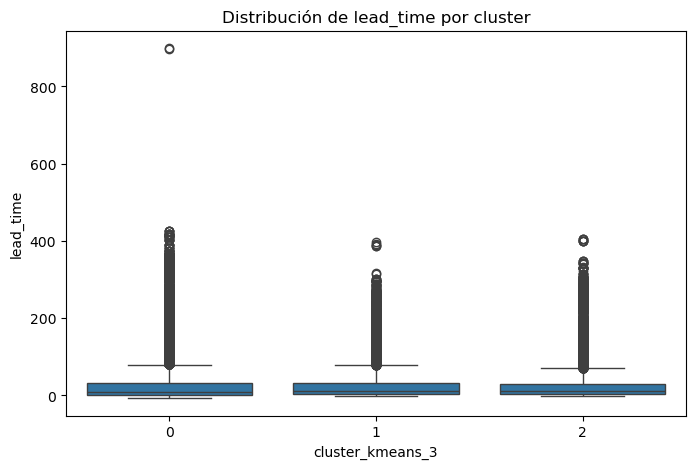

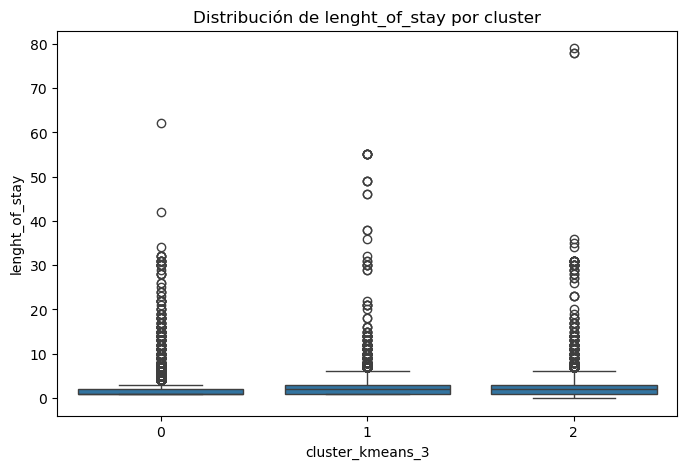

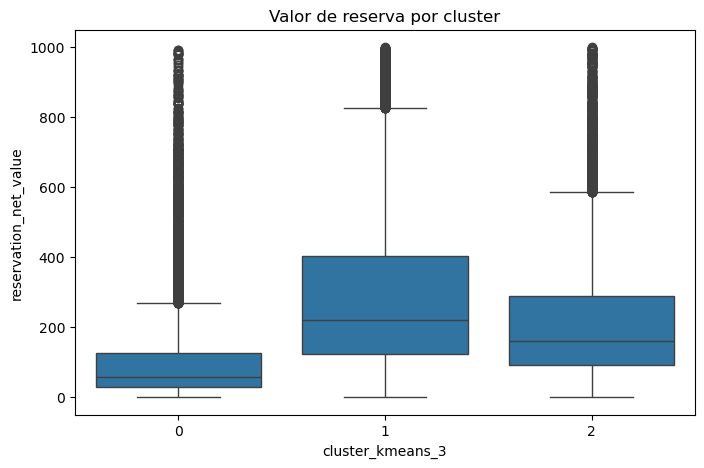

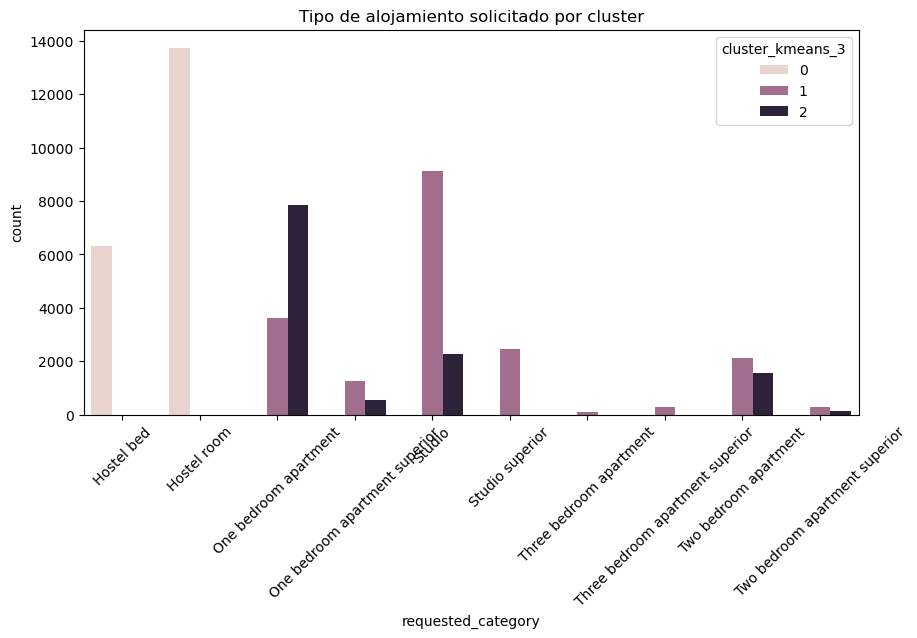

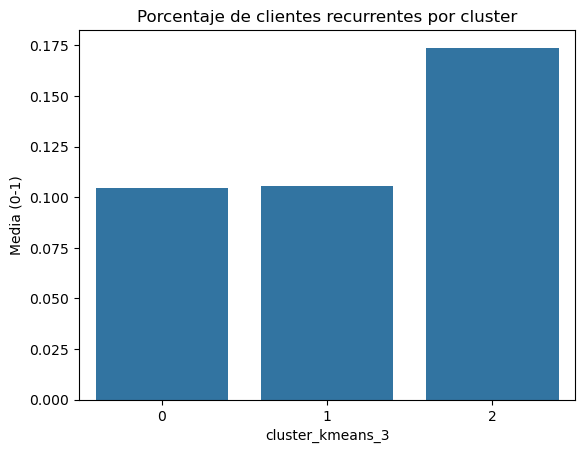

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de lead_time por cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='cluster_kmeans_3', y='lead_time', data=df)
plt.title('Distribución de lead_time por cluster')
plt.show()

# Distribución de lenght_of_stay por cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='cluster_kmeans_3', y='lenght_of_stay', data=df)
plt.title('Distribución de lenght_of_stay por cluster')
plt.show()

# Total reservation_net_value por cluster
plt.figure(figsize=(8,5))
sns.boxplot(x='cluster_kmeans_3', y='reservation_net_value', data=df)
plt.title('Valor de reserva por cluster')
plt.show()

# Conteo de requested_category por cluster
plt.figure(figsize=(10,5))
sns.countplot(x='requested_category', hue='cluster_kmeans_3', data=df)
plt.title('Tipo de alojamiento solicitado por cluster')
plt.xticks(rotation=45)
plt.show()

# Porcentaje de clientes recurrentes por cluster
recurrentes = df.groupby('cluster_kmeans_3')['returning_inhabitant_bin'].mean().reset_index()
sns.barplot(x='cluster_kmeans_3', y='returning_inhabitant_bin', data=recurrentes)
plt.title('Porcentaje de clientes recurrentes por cluster')
plt.ylabel('Media (0-1)')
plt.show()
